In [35]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
#
import deepchem.feat.molecule_featurizers.mol_graph_conv_featurizer as mgcf
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, accuracy_score, classification_report
#
import torch
import torch.nn as nn
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch.utils.data import DataLoader, Dataset, Subset
from torch_geometric.nn import GCNConv, GINConv, GATConv, global_mean_pool, global_add_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch.backends.cudnn as cudnn

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [36]:
# Hyperparameters
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 100
DROPOUT_P = 0.5
EARLY_STOP_PATIENCE = 5
PRINT_EVERY = 5
SPLIT_STRATEGY = "scaffold"  # options: 'scaffold' or 'random'
RANDOM_SEED = 42
TEST_RATIO = 0.2
VAL_RATIO = 0.2

import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)  # for multi-GPU

cudnn.deterministic = True
cudnn.benchmark = False

In [37]:
class GraphDataset(Dataset):
    def __init__(self, graphs, labels=None):
        self.graphs = graphs
        if labels is not None:
            self.labels = torch.tensor(labels, dtype=torch.float32)
        else:
            self.labels = None
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        if self.labels is not None:
            return self.graphs[idx], self.labels[idx]
        else:
            return self.graphs[idx]

In [38]:
#remove data when cov_label is 1 but crbn_chemspace is 0 (noise from general covalent database)
df_large_cov = pd.read_csv("final_dataset_for_classification.csv", index_col=False)
df_large_cov = df_large_cov[~((df_large_cov['cov_label'] == 1) & (df_large_cov['crbn_chemspace'] == 0))]
df_large_cov.reset_index(drop=True, inplace=True)

# Graph Featurization (ignore edge features for simplicity)
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
df_large_cov = df_large_cov.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
smiles = df_large_cov["smiles"].tolist()
graphs = list(featurizer.featurize(smiles))
y = df_large_cov["cov_crbn_label"].to_numpy().astype(np.float32)
dataset = GraphDataset(graphs, y)
num_features = dataset.graphs[0].node_features.shape[1]
print(f"Detected input feature dimension (num_features): {num_features}")

# Compute class imbalance-aware pos_weight for BCEWithLogitsLoss
pos_fraction = float(np.mean(y))
if pos_fraction > 0.0 and pos_fraction < 1.0:
    neg_fraction = 1.0 - pos_fraction
    pos_weight_value = neg_fraction / pos_fraction
else:
    pos_weight_value = 1.0
POS_WEIGHT_TENSOR = torch.tensor(pos_weight_value, device=device)
print(f"Using pos_weight: {pos_weight_value:.3f}")

Detected input feature dimension (num_features): 30
Using pos_weight: 1.700


In [39]:
# Scaffold split utilities (Bemis–Murcko)
def compute_scaffold(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split_indices(smiles_list, test_ratio=0.2, val_ratio=0.2, seed=RANDOM_SEED):
    """Return train/val/test indices using scaffold split for better generalization."""
    rng = np.random.default_rng(seed)
    scaffold_to_indices = {}
    for i, smi in enumerate(smiles_list):
        scaf = compute_scaffold(smi)
        scaffold_to_indices.setdefault(scaf, []).append(i)
    # Shuffle scaffolds deterministically
    scaffolds = list(scaffold_to_indices.keys())
    rng.shuffle(scaffolds)
    n = len(smiles_list)
    target_test = int(round(test_ratio * n))
    target_val = int(round(val_ratio * n))
    test_indices, val_indices, train_indices = [], [], []
    covered = set()
    for scaf in scaffolds:
        bucket = scaffold_to_indices[scaf]
        if len(test_indices) < target_test:
            test_indices.extend(bucket)
        elif len(val_indices) < target_val:
            val_indices.extend(bucket)
        else:
            train_indices.extend(bucket)
        covered.update(bucket)
    assert len(covered) == n, "Scaffold split did not cover all samples"
    return np.array(train_indices), np.array(val_indices), np.array(test_indices)

def graph_collate(batch):
    graphs_batch, labels_batch = zip(*batch)
    return list(graphs_batch), torch.stack(labels_batch)

def split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE):
    n_samples = len(dataset)
    train_ratio = 1.0 - TEST_RATIO - VAL_RATIO
    indices = np.arange(n_samples)
    if SPLIT_STRATEGY == "scaffold":
        ids_train, ids_val, ids_test = scaffold_split_indices(
            smiles,
            test_ratio=TEST_RATIO,
            val_ratio=VAL_RATIO,
            seed=seed,
        )
    else:
        ids_train_val, ids_test, _, _ = train_test_split(
            indices,
            y,
            test_size=TEST_RATIO, 
            random_state=seed, 
            stratify=y
        )
        relative_val_ratio = VAL_RATIO / (train_ratio + VAL_RATIO)
        ids_train, ids_val, _, _ = train_test_split(
            ids_train_val, 
            y[ids_train_val], 
            test_size=relative_val_ratio, 
            random_state=seed, 
            stratify=y[ids_train_val]
        )
    #
    train_loader = DataLoader(
        Subset(dataset, ids_train),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of training samples: {len(ids_train)}")
    val_loader = DataLoader(
        Subset(dataset, ids_val),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of validation samples: {len(ids_val)}")
    test_loader = DataLoader(
        Subset(dataset, ids_test),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    #print(f"Number of test samples: {len(ids_test)}")
    return train_loader, val_loader, test_loader

In [40]:
# TRAIN/VALIDATION/TEST UTILITIES
def reset_all_seeds(seed=RANDOM_SEED):
    """Reset ALL sources of randomness for perfect reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_model(model, train_loader, val_loader, epochs, optimizer, criterion, device, print_every=5, scheduler=None, early_stop_patience=None):
    """Train model, with optional LR scheduler and early stopping by MCC."""
    best_mcc = -1.0
    best_state = None
    patience_left = early_stop_patience if early_stop_patience is not None else None
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        for graphs_batch, labels_batch in train_loader:
            optimizer.zero_grad()
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(labels_batch)
            total_count += len(labels_batch)
        avg_train_loss = total_loss / total_count if total_count > 0 else float("nan")
        # Compute MCC via threshold optimization for validation
        _, val_mcc = optimize_threshold(model, val_loader, device)
        # Keep scheduler on MCC signal
        if scheduler is not None and val_mcc is not None:
            scheduler.step(val_mcc)
        # Early stopping tracking
        if val_mcc > best_mcc:
            best_mcc = val_mcc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if patience_left is not None:
                patience_left = early_stop_patience
        else:
            if patience_left is not None:
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stopping at epoch {epoch:02d} | Best MCC: {best_mcc:.4f}")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break
        if epoch % print_every == 0:
            print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val MCC (opt thr): {val_mcc:.4f}")
    # Restore best state at end if not already
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def optimize_threshold(model, loader, device, grid=None):
    """Find probability threshold maximizing validation MCC."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for graphs_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels_batch.detach().cpu())
    if len(all_logits) == 0:
        return 0.5, -1.0
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1.0 / (1.0 + np.exp(-logits))
    best_thr, best_mcc = 0.5, -1.0
    for t in grid:
        preds = (probs > t).astype(np.float32)
        try:
            mcc = matthews_corrcoef(labels, preds)
        except Exception:
            mcc = -1.0
        if np.isnan(mcc):
            mcc = -1.0
        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = float(t)
    return best_thr, best_mcc

def evaluate_model(model, loader, device, criterion=None, threshold=0.5):
    """Run model in eval mode over loader and return predictions, labels, and optional avg loss."""
    model.eval()
    preds = []
    labels = []
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for graphs_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            logits = model(graphs_batch)
            if criterion is not None:
                total_loss += criterion(logits, labels_batch).item() * len(labels_batch)
            probs = torch.sigmoid(logits)
            batch_preds = (probs > threshold).float()
            preds.extend(batch_preds.cpu().numpy())
            labels.extend(labels_batch.cpu().numpy())
            total_count += len(labels_batch)
    avg_loss = total_loss / total_count if criterion is not None and total_count > 0 else None
    return preds, labels, avg_loss

def training_and_evaluation(model_class, train_loader, val_loader, test_loader, num_features, hidden_dim=HIDDEN_DIM, seed=RANDOM_SEED, lr=LEARNING_RATE, epochs=EPOCHS, print_every=PRINT_EVERY, early_stop_patience=EARLY_STOP_PATIENCE, device='cuda'):

    reset_all_seeds(seed)
    model = model_class(in_features=num_features, dim_h=hidden_dim).to(device)
    model_type = model.__class__.__name__
    print(f"\nTraining model: {model_type}")
    
    reset_all_seeds(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT_TENSOR)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
    
    # TRAINING
    reset_all_seeds(seed)
    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        print_every=print_every,
        scheduler=scheduler,
        early_stop_patience=early_stop_patience,
    )

    # OPTIMIZE THRESHOLD ON VALIDATION SET
    reset_all_seeds(seed)
    best_thr, _ = optimize_threshold(model, val_loader, device)
    print(f"Optimized threshold: {best_thr:.3f}")

    # EVALUATION ON TEST SET
    reset_all_seeds(seed)
    model.eval()
    test_preds, test_labels, _ = evaluate_model(
        model, test_loader, device, criterion, threshold=best_thr
    )
    test_accuracy = accuracy_score(test_labels, test_preds)
    test_mcc = matthews_corrcoef(test_labels, test_preds)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test MCC: {test_mcc:.4f}")

    # EVALUATION ON NEW DATA
    #reset_all_seeds(seed)
    #for c, ii in enumerate([gen_set_1, gen_set_2, gen_set_3]):
        #gen_loader = predict_gen(ii)
        #preds, _, _ = evaluate_model(
            #model, gen_loader, device, criterion, threshold=best_thr
        #)
        #if ii == gen_set_2:
            #print(f'Accuracy on gen{c+1}= {preds.count(0)/len(preds):.3f}')
        #else:
            #print(f'Accuracy on gen{c+1}= {preds.count(1)/len(preds):.3f}')

    return model, best_thr, test_accuracy, test_mcc

def gen_loader(smiles_list):
    featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
    graphs = list(featurizer.featurize(smiles_list))
    labels_placeholder = np.zeros(len(graphs), dtype=np.float32)  # dummy labels to satisfy collate
    dataset = GraphDataset(graphs, labels_placeholder)
    num_features = dataset.graphs[0].node_features.shape[1]
    #print(f"Detected input feature dimension (num_features): {num_features}")
    test_loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=graph_collate,
    )
    return test_loader

def predict_combined_accuracy_and_mcc(model, sets_with_labels, threshold, batch_size, device):
    """Predict multiple sets combined and return accuracy and MCC."""
    featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)
    combined_smiles = []
    combined_labels = []
    for smiles_list, label_value in sets_with_labels:
        combined_smiles.extend(smiles_list)
        combined_labels.extend([label_value] * len(smiles_list))
    graphs = list(featurizer.featurize(combined_smiles))
    labels_placeholder = np.zeros(len(graphs), dtype=np.float32)
    dataset = GraphDataset(graphs, labels_placeholder)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=graph_collate,
    )
    preds, _, _ = evaluate_model(model, loader, device, threshold=threshold)
    preds_int = [int(p) for p in preds]
    acc = accuracy_score(combined_labels, preds_int)
    mcc = matthews_corrcoef(combined_labels, preds_int)
    return acc, mcc

In [41]:
# GCN MODEL DEFINITION
class GCN(torch.nn.Module):


    """Graph Convolutional Network class with 3 convolutional layers and a linear layer"""

    def __init__(self, in_features, dim_h):
        super().__init__()
        self.conv1 = GCNConv(in_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GCNConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GCN layers
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        
        # Global Pooling (Graph-level prediction)
        # A visualization of message passing, node embedding, and global pooling 
        # might be helpful here. 
        x = global_mean_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)

        return x.squeeze(-1) # Squeeze to shape [batch_size]    
# GIN MODEL DEFINITION
class GIN(torch.nn.Module):
    """Graph Isomorphism Network class with 3 GINConv layers and 1 linear layer
    
    Note: BatchNorm is essential for GIN stability because:
    - GIN uses sum aggregation (scale-dependent)
    - Deeper MLPs (2 Linear layers) need normalization
    - Prevents gradient instability during training
    
    GIN uses global_add_pool (SUM) rather than global_mean_pool because:
    - Preserves injectivity required for WL-test expressiveness
    - Different graph structures produce different sums (but may have same mean)
    - This is GIN's key theoretical advantage over GCN/GAT
    """

    def __init__(self, in_features, dim_h):
        """Initializing GIN class

        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
        """
        super(GIN, self).__init__()
        # Add BatchNorm for stability - critical for GIN!
        self.conv1 = GINConv(
            Sequential(Linear(in_features, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.lin = Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GINConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GIN layers with sum aggregation (more powerful but needs BatchNorm)
        x = self.conv1(x, e)
        x = self.conv2(x, e)
        x = self.conv3(x, e)
        
        # Global Pooling: Use SUM for GIN to preserve theoretical properties
        # This maintains injectivity - different graphs → different representations
        x = global_add_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)
        return x.squeeze(-1) # Squeeze to shape [batch_size]    
# GAT MODEL DEFINITION
class GAT(torch.nn.Module):
    """Graph Attention Network class with 3 GATConv layers and 1 linear layer"""

    def __init__(self, in_features, dim_h, heads=3):
        """Initializing GAT class

        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
            heads (int): number of attention heads
        """
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_features, dim_h, heads=heads, concat=True)
        self.conv2 = GATConv(dim_h * heads, dim_h, heads=heads, concat=True)
        self.conv3 = GATConv(dim_h * heads, dim_h, heads=1, concat=False)
        self.lin = Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GATConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GAT layers with attention mechanism
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        
        # Global Pooling (Graph-level prediction)
        x = global_mean_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)

        return x.squeeze(-1) # Squeeze to shape [batch_size]

In [8]:
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 42

In [9]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)


Training model: GCN
Epoch 05 | Train Loss: 0.5504 | Val MCC (opt thr): 0.9009
Epoch 10 | Train Loss: 0.2746 | Val MCC (opt thr): 0.9418
Epoch 15 | Train Loss: 0.2431 | Val MCC (opt thr): 0.9434
Epoch 20 | Train Loss: 0.2130 | Val MCC (opt thr): 0.9514
Epoch 25 | Train Loss: 0.1928 | Val MCC (opt thr): 0.9562
Epoch 30 | Train Loss: 0.1789 | Val MCC (opt thr): 0.9626
Epoch 35 | Train Loss: 0.1607 | Val MCC (opt thr): 0.9640
Epoch 40 | Train Loss: 0.1487 | Val MCC (opt thr): 0.9671
Epoch 45 | Train Loss: 0.1409 | Val MCC (opt thr): 0.9687
Early stopping at epoch 48 | Best MCC: 0.9687
Optimized threshold: 0.600
Test Accuracy: 0.9803
Test MCC: 0.9581


In [10]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)


Training model: GCN
Epoch 05 | Train Loss: 0.4091 | Val MCC (opt thr): 0.9218
Epoch 10 | Train Loss: 0.2203 | Val MCC (opt thr): 0.9312
Epoch 15 | Train Loss: 0.1717 | Val MCC (opt thr): 0.9345
Epoch 20 | Train Loss: 0.1385 | Val MCC (opt thr): 0.9486
Epoch 25 | Train Loss: 0.1169 | Val MCC (opt thr): 0.9563
Epoch 30 | Train Loss: 0.0959 | Val MCC (opt thr): 0.9593
Epoch 35 | Train Loss: 0.0845 | Val MCC (opt thr): 0.9640
Epoch 40 | Train Loss: 0.0786 | Val MCC (opt thr): 0.9656
Early stopping at epoch 41 | Best MCC: 0.9656
Optimized threshold: 0.500
Test Accuracy: 0.9777
Test MCC: 0.9503


In [11]:
gcn_model, thr, _, _ = training_and_evaluation(GCN, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)


Training model: GCN
Epoch 05 | Train Loss: 0.4012 | Val MCC (opt thr): 0.9227
Epoch 10 | Train Loss: 0.2166 | Val MCC (opt thr): 0.9382
Epoch 15 | Train Loss: 0.1790 | Val MCC (opt thr): 0.9414
Epoch 20 | Train Loss: 0.1513 | Val MCC (opt thr): 0.9494
Epoch 25 | Train Loss: 0.1241 | Val MCC (opt thr): 0.9526
Early stopping at epoch 28 | Best MCC: 0.9526
Optimized threshold: 0.800
Test Accuracy: 0.9772
Test MCC: 0.9525


In [10]:
BATCH_SIZE = 32
HIDDEN_DIM = 32
LEARNING_RATE = 0.005 
RANDOM_SEED = 42

In [11]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)


Training model: GAT
Epoch 05 | Train Loss: 0.2291 | Val MCC (opt thr): 0.9592
Epoch 10 | Train Loss: 0.1672 | Val MCC (opt thr): 0.9658
Epoch 15 | Train Loss: 0.1185 | Val MCC (opt thr): 0.9812
Epoch 20 | Train Loss: 0.0658 | Val MCC (opt thr): 0.9859
Epoch 25 | Train Loss: 0.0541 | Val MCC (opt thr): 0.9890
Epoch 30 | Train Loss: 0.0515 | Val MCC (opt thr): 0.9953
Early stopping at epoch 35 | Best MCC: 0.9953
Optimized threshold: 0.300
Test Accuracy: 0.9932
Test MCC: 0.9855


In [14]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)


Training model: GAT
Epoch 05 | Train Loss: 0.1853 | Val MCC (opt thr): 0.9503
Epoch 10 | Train Loss: 0.1192 | Val MCC (opt thr): 0.9501
Epoch 15 | Train Loss: 0.0887 | Val MCC (opt thr): 0.9578
Epoch 20 | Train Loss: 0.0669 | Val MCC (opt thr): 0.9640
Epoch 25 | Train Loss: 0.0541 | Val MCC (opt thr): 0.9736
Epoch 30 | Train Loss: 0.0472 | Val MCC (opt thr): 0.9766
Early stopping at epoch 33 | Best MCC: 0.9766
Optimized threshold: 0.450
Test Accuracy: 0.9861
Test MCC: 0.9691


In [15]:
gat_model, thr, _, _ = training_and_evaluation(GAT, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)


Training model: GAT
Epoch 05 | Train Loss: 0.1834 | Val MCC (opt thr): 0.9494
Epoch 10 | Train Loss: 0.1083 | Val MCC (opt thr): 0.9558
Early stopping at epoch 14 | Best MCC: 0.9558
Optimized threshold: 0.850
Test Accuracy: 0.9765
Test MCC: 0.9510


In [12]:
BATCH_SIZE = 16
HIDDEN_DIM = 64
LEARNING_RATE = 0.001
RANDOM_SEED = 42

In [13]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=42, batch_size=BATCH_SIZE), num_features, seed=42)


Training model: GIN
Epoch 05 | Train Loss: 0.1726 | Val MCC (opt thr): 0.9797
Epoch 10 | Train Loss: 0.0947 | Val MCC (opt thr): 0.9689
Early stopping at epoch 11 | Best MCC: 0.9922
Optimized threshold: 0.650
Test Accuracy: 0.9947
Test MCC: 0.9887


In [18]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=21, batch_size=BATCH_SIZE), num_features, seed=21)


Training model: GIN
Epoch 05 | Train Loss: 0.1920 | Val MCC (opt thr): 0.9781
Epoch 10 | Train Loss: 0.1127 | Val MCC (opt thr): 0.9812
Epoch 15 | Train Loss: 0.0797 | Val MCC (opt thr): 0.9828
Early stopping at epoch 16 | Best MCC: 0.9859
Optimized threshold: 0.600
Test Accuracy: 0.9909
Test MCC: 0.9798


In [19]:
gin_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=0, batch_size=BATCH_SIZE), num_features, seed=0)


Training model: GIN
Epoch 05 | Train Loss: 0.1575 | Val MCC (opt thr): 0.9779
Epoch 10 | Train Loss: 0.0778 | Val MCC (opt thr): 0.9795
Epoch 15 | Train Loss: 0.0512 | Val MCC (opt thr): 0.9794
Epoch 20 | Train Loss: 0.0382 | Val MCC (opt thr): 0.9875
Early stopping at epoch 21 | Best MCC: 0.9875
Optimized threshold: 0.850
Test Accuracy: 0.9879
Test MCC: 0.9746


In [42]:
gen_set_1_1 = pd.read_csv("../genAI/smiles_rnn_test/cleaned_fresh_imide_molecules_top100_QED_approach1.csv", index_col=False)["SMILES"].tolist()
gen_set_1_2 = pd.read_csv("../genAI/smiles_rnn_test/cleaned_fresh_imide_molecules_top100_QED_approach2.csv", index_col=False)["SMILES"].tolist()
gen_set_1 = gen_set_1_1 + gen_set_1_2
#remove duplicates
gen_set_1 = list(set(gen_set_1))
print(f'Number of unique molecules in gen_set_1: {len(gen_set_1)}')

Number of unique molecules in gen_set_1: 198


In [43]:
gen_set_2 = pd.read_csv("../genAI/reinvent4_test/cleaned_fresh_imide_molecules_top200_QED.csv", index_col=False)["SMILES"].tolist()
gen_set_2 = list(set(gen_set_2))
print(f'Number of unique molecules in gen_set_2: {len(gen_set_2)}')

Number of unique molecules in gen_set_2: 200


In [44]:
gen_set_combined = list(set(gen_set_1 + gen_set_2)) 
print(f'Number of unique molecules in gen_set_combined: {len(gen_set_combined)}')

Number of unique molecules in gen_set_combined: 398


In [45]:
cov_dock_set = pd.read_csv("../covalent_docking_VS/covalent_docking_unique_2D_precursors_QED_filtered_above_049.csv", index_col=False)["SMILES"].tolist()
cov_dock_set = list(set(cov_dock_set))
print(f'Number of unique molecules in cov_dock_set: {len(cov_dock_set)}')

Number of unique molecules in cov_dock_set: 156


In [23]:
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 42
predict_combined_accuracy_and_mcc(gcn_model,[(gen_set_combined, 0), (cov_dock_set, 1),], 0.6, BATCH_SIZE, device)

(0.9891696750902527, 0.9738818888194587)

In [24]:
BATCH_SIZE = 32
HIDDEN_DIM = 32
LEARNING_RATE = 0.005 
RANDOM_SEED = 42
predict_combined_accuracy_and_mcc(gat_model, [(gen_set_combined, 0), (cov_dock_set, 1),], 0.3, BATCH_SIZE, device)

(0.9927797833935018, 0.9824464387563964)

In [27]:
BATCH_SIZE = 16
HIDDEN_DIM = 64
LEARNING_RATE = 0.001
RANDOM_SEED = 42
predict_combined_accuracy_and_mcc(gin_model, [(gen_set_combined, 0), (cov_dock_set, 1),], 0.65, BATCH_SIZE, device)

(0.9963898916967509, 0.9911509752348148)

In [28]:
# HYPERPARAMETER SCREENING

import itertools
import math
from datetime import datetime

# Define hyperparameter grid
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
HIDDEN_DIM_GRID = [8, 16, 32, 64]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
RANDOM_SEED_GRID = [42, 21, 0]

# Storage for results - now includes seed information
results_per_seed = []

# Total combinations
total_combinations = len(BATCH_SIZE_GRID) * len(HIDDEN_DIM_GRID) * len(LEARNING_RATE_GRID) * len(RANDOM_SEED_GRID)
print(f"Starting hyperparameter screening with {total_combinations} combinations...")
print(f"(Testing {len(BATCH_SIZE_GRID)} batch sizes × {len(HIDDEN_DIM_GRID)} hidden dims × {len(LEARNING_RATE_GRID)} learning rates × {len(RANDOM_SEED_GRID)} seeds)")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 100)

combination_counter = 0

for batch_size, hidden_dim, lr, seed in itertools.product(BATCH_SIZE_GRID, HIDDEN_DIM_GRID, LEARNING_RATE_GRID, RANDOM_SEED_GRID):
    combination_counter += 1
    print(f"\n[{combination_counter}/{total_combinations}] Testing: BATCH_SIZE={batch_size}, HIDDEN_DIM={hidden_dim}, LR={lr}, SEED={seed}")
    
    train_loader_temp, val_loader_temp, test_loader_temp = split_dataframe(dataset, y, seed, batch_size)
    
    # GCN
    model_temp, thr_temp, gcn_test_accuracy, gcn_test_mcc = training_and_evaluation(
        model_class=GCN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gcn_gen_all_acc, gcn_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_combined, 0),
            (cov_dock_set, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # GIN
    model_temp, thr_temp, gin_test_accuracy, gin_test_mcc = training_and_evaluation(
        model_class=GIN,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gin_gen_all_acc, gin_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_combined, 0),
            (cov_dock_set, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # GAT
    model_temp, thr_temp, gat_test_accuracy, gat_test_mcc = training_and_evaluation(
        model_class=GAT,
        train_loader=train_loader_temp, 
        val_loader=val_loader_temp, 
        test_loader=test_loader_temp, 
        num_features=num_features,
        hidden_dim=hidden_dim,
        seed=seed,
        lr=lr,
    )
    gat_gen_all_acc, gat_gen_all_mcc = predict_combined_accuracy_and_mcc(
        model_temp,
        [
            (gen_set_combined, 0),
            (cov_dock_set, 1),
        ],
        thr_temp,
        batch_size,
        device,
    )
    
    # Store results with seed information
    result = {
        'batch_size': batch_size,
        'hidden_dim': hidden_dim,
        'learning_rate': lr,
        'random_seed': seed,
        # GCN
        'gcn_test_acc': gcn_test_accuracy,
        'gcn_test_mcc': gcn_test_mcc,
        'gcn_gen_all_acc': gcn_gen_all_acc,
        'gcn_gen_all_mcc': gcn_gen_all_mcc,
        # GIN
        'gin_test_acc': gin_test_accuracy,
        'gin_test_mcc': gin_test_mcc,
        'gin_gen_all_acc': gin_gen_all_acc,
        'gin_gen_all_mcc': gin_gen_all_mcc,
        # GAT
        'gat_test_acc': gat_test_accuracy,
        'gat_test_mcc': gat_test_mcc,
        'gat_gen_all_acc': gat_gen_all_acc,
        'gat_gen_all_mcc': gat_gen_all_mcc,
    }
    results_per_seed.append(result)

print("\n" + "=" * 100)
print(f"Screening completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total combinations tested: {len(results_per_seed)}")
print(f"Unique hyperparameter combinations: {len(results_per_seed) // len(RANDOM_SEED_GRID)}")


Starting hyperparameter screening with 180 combinations...
(Testing 5 batch sizes × 4 hidden dims × 3 learning rates × 3 seeds)
Started at: 2026-02-04 13:49:48

[1/180] Testing: BATCH_SIZE=16, HIDDEN_DIM=8, LR=0.001, SEED=42

Training model: GCN
Epoch 05 | Train Loss: 0.3758 | Val MCC (opt thr): 0.9387
Epoch 10 | Train Loss: 0.2347 | Val MCC (opt thr): 0.9545
Epoch 15 | Train Loss: 0.1821 | Val MCC (opt thr): 0.9643
Epoch 20 | Train Loss: 0.1539 | Val MCC (opt thr): 0.9658
Epoch 25 | Train Loss: 0.1487 | Val MCC (opt thr): 0.9657
Early stopping at epoch 28 | Best MCC: 0.9673
Optimized threshold: 0.800
Test Accuracy: 0.9810
Test MCC: 0.9599

Training model: GIN
Epoch 05 | Train Loss: 0.4264 | Val MCC (opt thr): 0.9565
Epoch 10 | Train Loss: 0.3147 | Val MCC (opt thr): 0.9812
Epoch 15 | Train Loss: 0.2520 | Val MCC (opt thr): 0.9890
Early stopping at epoch 16 | Best MCC: 0.9890
Optimized threshold: 0.450
Test Accuracy: 0.9947
Test MCC: 0.9887

Training model: GAT
Epoch 05 | Train Loss: 0

/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Epoch 05 | Train Loss: 0.6878 | Val MCC (opt thr): 0.9186
Epoch 10 | Train Loss: 0.4578 | Val MCC (opt thr): 0.9471
Epoch 15 | Train Loss: 0.4029 | Val MCC (opt thr): 0.9501
Epoch 20 | Train Loss: 0.3659 | Val MCC (opt thr): 0.9518
Epoch 25 | Train Loss: 0.3514 | Val MCC (opt thr): 0.9640
Epoch 30 | Train Loss: 0.3512 | Val MCC (opt thr): 0.9718
Early stopping at epoch 33 | Best MCC: 0.9750
Optimized threshold: 0.650
Test Accuracy: 0.9875
Test MCC: 0.9720

Training model: GAT
Epoch 05 | Train Loss: 0.2466 | Val MCC (opt thr): 0.9453
Epoch 10 | Train Loss: 0.2014 | Val MCC (opt thr): 0.9455
Early stopping at epoch 11 | Best MCC: 0.9501
Optimized threshold: 0.950
Test Accuracy: 0.9763
Test MCC: 0.9470

[6/180] Testing: BATCH_SIZE=16, HIDDEN_DIM=8, LR=0.0005, SEED=0

Training model: GCN
Epoch 05 | Train Loss: 0.8184 | Val MCC (opt thr): 0.3768
Epoch 10 | Train Loss: 0.6233 | Val MCC (opt thr): 0.6111
Epoch 15 | Train Loss: 0.4175 | Val MCC (opt thr): 0.8365
Epoch 20 | Train Loss: 0.3253 |

/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Epoch 05 | Train Loss: 2.1228 | Val MCC (opt thr): 0.6137


...

Epoch 05 | Train Loss: 6.1476 | Val MCC (opt thr): 0.0000


/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Early stopping at epoch 06 | Best MCC: 0.0000
Optimized threshold: 0.100
Test Accuracy: 0.6588
Test MCC: -0.0328

Training model: GAT
Epoch 05 | Train Loss: 0.8707 | Val MCC (opt thr): 0.0000
Early stopping at epoch 06 | Best MCC: 0.0000
Optimized threshold: 0.050
Test Accuracy: 0.3391
Test MCC: 0.0000

[153/180] Testing: BATCH_SIZE=256, HIDDEN_DIM=8, LR=0.0001, SEED=0

Training model: GCN
Epoch 05 | Train Loss: 0.8704 | Val MCC (opt thr): 0.0000
Early stopping at epoch 06 | Best MCC: 0.0000
Optimized threshold: 0.050
Test Accuracy: 0.3945
Test MCC: 0.0000

Training model: GIN
Epoch 05 | Train Loss: 2.5497 | Val MCC (opt thr): 0.2830
Epoch 10 | Train Loss: 2.1027 | Val MCC (opt thr): 0.4907
Epoch 15 | Train Loss: 1.7738 | Val MCC (opt thr): 0.5992
Epoch 20 | Train Loss: 1.5492 | Val MCC (opt thr): 0.6994
Epoch 25 | Train Loss: 1.3507 | Val MCC (opt thr): 0.7452
Epoch 30 | Train Loss: 1.1959 | Val MCC (opt thr): 0.8012
Epoch 35 | Train Loss: 1.0048 | Val MCC (opt thr): 0.8422
Epoch 40 |

/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))
/tmp/ipykernel_1033886/3565574185.py:73: RuntimeWarning: overflow encountered in exp
  probs = 1.0 / (1.0 + np.exp(-logits))


Epoch 10 | Train Loss: 0.4118 | Val MCC (opt thr): 0.9541
Epoch 15 | Train Loss: 0.2142 | Val MCC (opt thr): 0.9620
Epoch 20 | Train Loss: 0.1746 | Val MCC (opt thr): 0.9668
Epoch 25 | Train Loss: 0.1022 | Val MCC (opt thr): 0.9684
Epoch 30 | Train Loss: 0.0909 | Val MCC (opt thr): 0.9700
Early stopping at epoch 32 | Best MCC: 0.9747
Optimized threshold: 0.650
Test Accuracy: 0.9780
Test MCC: 0.9540

Training model: GAT
Epoch 05 | Train Loss: 0.8418 | Val MCC (opt thr): 0.3765
Epoch 10 | Train Loss: 0.4366 | Val MCC (opt thr): 0.8513
Epoch 15 | Train Loss: 0.2521 | Val MCC (opt thr): 0.9351
Epoch 20 | Train Loss: 0.1964 | Val MCC (opt thr): 0.9446
Epoch 25 | Train Loss: 0.1742 | Val MCC (opt thr): 0.9494
Early stopping at epoch 27 | Best MCC: 0.9494
Optimized threshold: 0.900
Test Accuracy: 0.9727
Test MCC: 0.9431

[169/180] Testing: BATCH_SIZE=256, HIDDEN_DIM=32, LR=0.0001, SEED=42

Training model: GCN
Epoch 05 | Train Loss: 0.8628 | Val MCC (opt thr): 0.0000
Early stopping at epoch 06

In [29]:
# Convert results to DataFrame
results_per_seed_df = pd.DataFrame(results_per_seed)
results_per_seed_df.to_csv('hyperparameter_screening_results_per_seed.csv', index=False)

In [30]:
# Aggregate results by taking mean across random seeds
metric_cols = [col for col in results_per_seed_df.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
results_df = results_per_seed_df.groupby(['batch_size', 'hidden_dim', 'learning_rate'])[metric_cols].mean().reset_index()
results_df.to_csv('hyperparameter_screening_results.csv', index=False)

In [31]:
# ANALYSIS - Summary statistics

def print_stats(label, values):
    """Helper to print mean, std, min, max for a metric."""
    return f"{label}: {values.mean():.4f} ± {values.std():.4f} (min: {values.min():.4f}, max: {values.max():.4f})"

print(f"\n{'='*100}")
print(f"SUMMARY STATISTICS (averaged across {len(RANDOM_SEED_GRID)} seeds per hyperparameter combination)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    print(f"\n{model.upper()}:")
    print(f"  {print_stats('Test MCC', results_df[f'{model}_test_mcc'])}")
    print(f"  {print_stats('Combined Gen MCC', results_df[f'{model}_gen_all_mcc'])}")

# Best hyperparameters analysis
print(f"\n{'='*100}")
print(f"BEST HYPERPARAMETERS for Combined Gen MCC (across {len(RANDOM_SEED_GRID)} seeds)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    best_idx = results_df[f'{model}_gen_all_mcc'].idxmax()
    best_row = results_df.iloc[best_idx]
    
    # Filter per-seed results for best hyperparameters
    best_per_seed = results_per_seed_df[
        (results_per_seed_df['batch_size'] == best_row['batch_size']) &
        (results_per_seed_df['hidden_dim'] == best_row['hidden_dim']) &
        (results_per_seed_df['learning_rate'] == best_row['learning_rate'])
    ]
    
    print(f"\nBest {model.upper()}: BS={int(best_row['batch_size'])}, HD={int(best_row['hidden_dim'])}, LR={best_row['learning_rate']}")
    print(f"  {print_stats('Test MCC', best_per_seed[f'{model}_test_mcc'])}")
    print(f"  {print_stats('Gen MCC', best_per_seed[f'{model}_gen_all_mcc'])}")



SUMMARY STATISTICS (averaged across 3 seeds per hyperparameter combination)

GCN:
  Test MCC: 0.6555 ± 0.3636 (min: -0.0072, max: 0.9718)
  Combined Gen MCC: 0.6885 ± 0.3679 (min: 0.0000, max: 1.0000)

GIN:
  Test MCC: 0.9536 ± 0.0728 (min: 0.5525, max: 0.9826)
  Combined Gen MCC: 0.9728 ± 0.0725 (min: 0.5531, max: 0.9971)

GAT:
  Test MCC: 0.7790 ± 0.3156 (min: 0.0000, max: 0.9743)
  Combined Gen MCC: 0.7957 ± 0.3325 (min: -0.0211, max: 1.0000)

BEST HYPERPARAMETERS for Combined Gen MCC (across 3 seeds)

Best GCN: BS=32, HD=64, LR=0.001
  Test MCC: 0.9552 ± 0.0045 (min: 0.9510, max: 0.9599)
  Gen MCC: 1.0000 ± 0.0000 (min: 1.0000, max: 1.0000)

Best GIN: BS=128, HD=8, LR=0.0005
  Test MCC: 0.9533 ± 0.0214 (min: 0.9368, max: 0.9775)
  Gen MCC: 0.9971 ± 0.0051 (min: 0.9912, max: 1.0000)

Best GAT: BS=16, HD=8, LR=0.001
  Test MCC: 0.9568 ± 0.0085 (min: 0.9478, max: 0.9647)
  Gen MCC: 1.0000 ± 0.0000 (min: 1.0000, max: 1.0000)


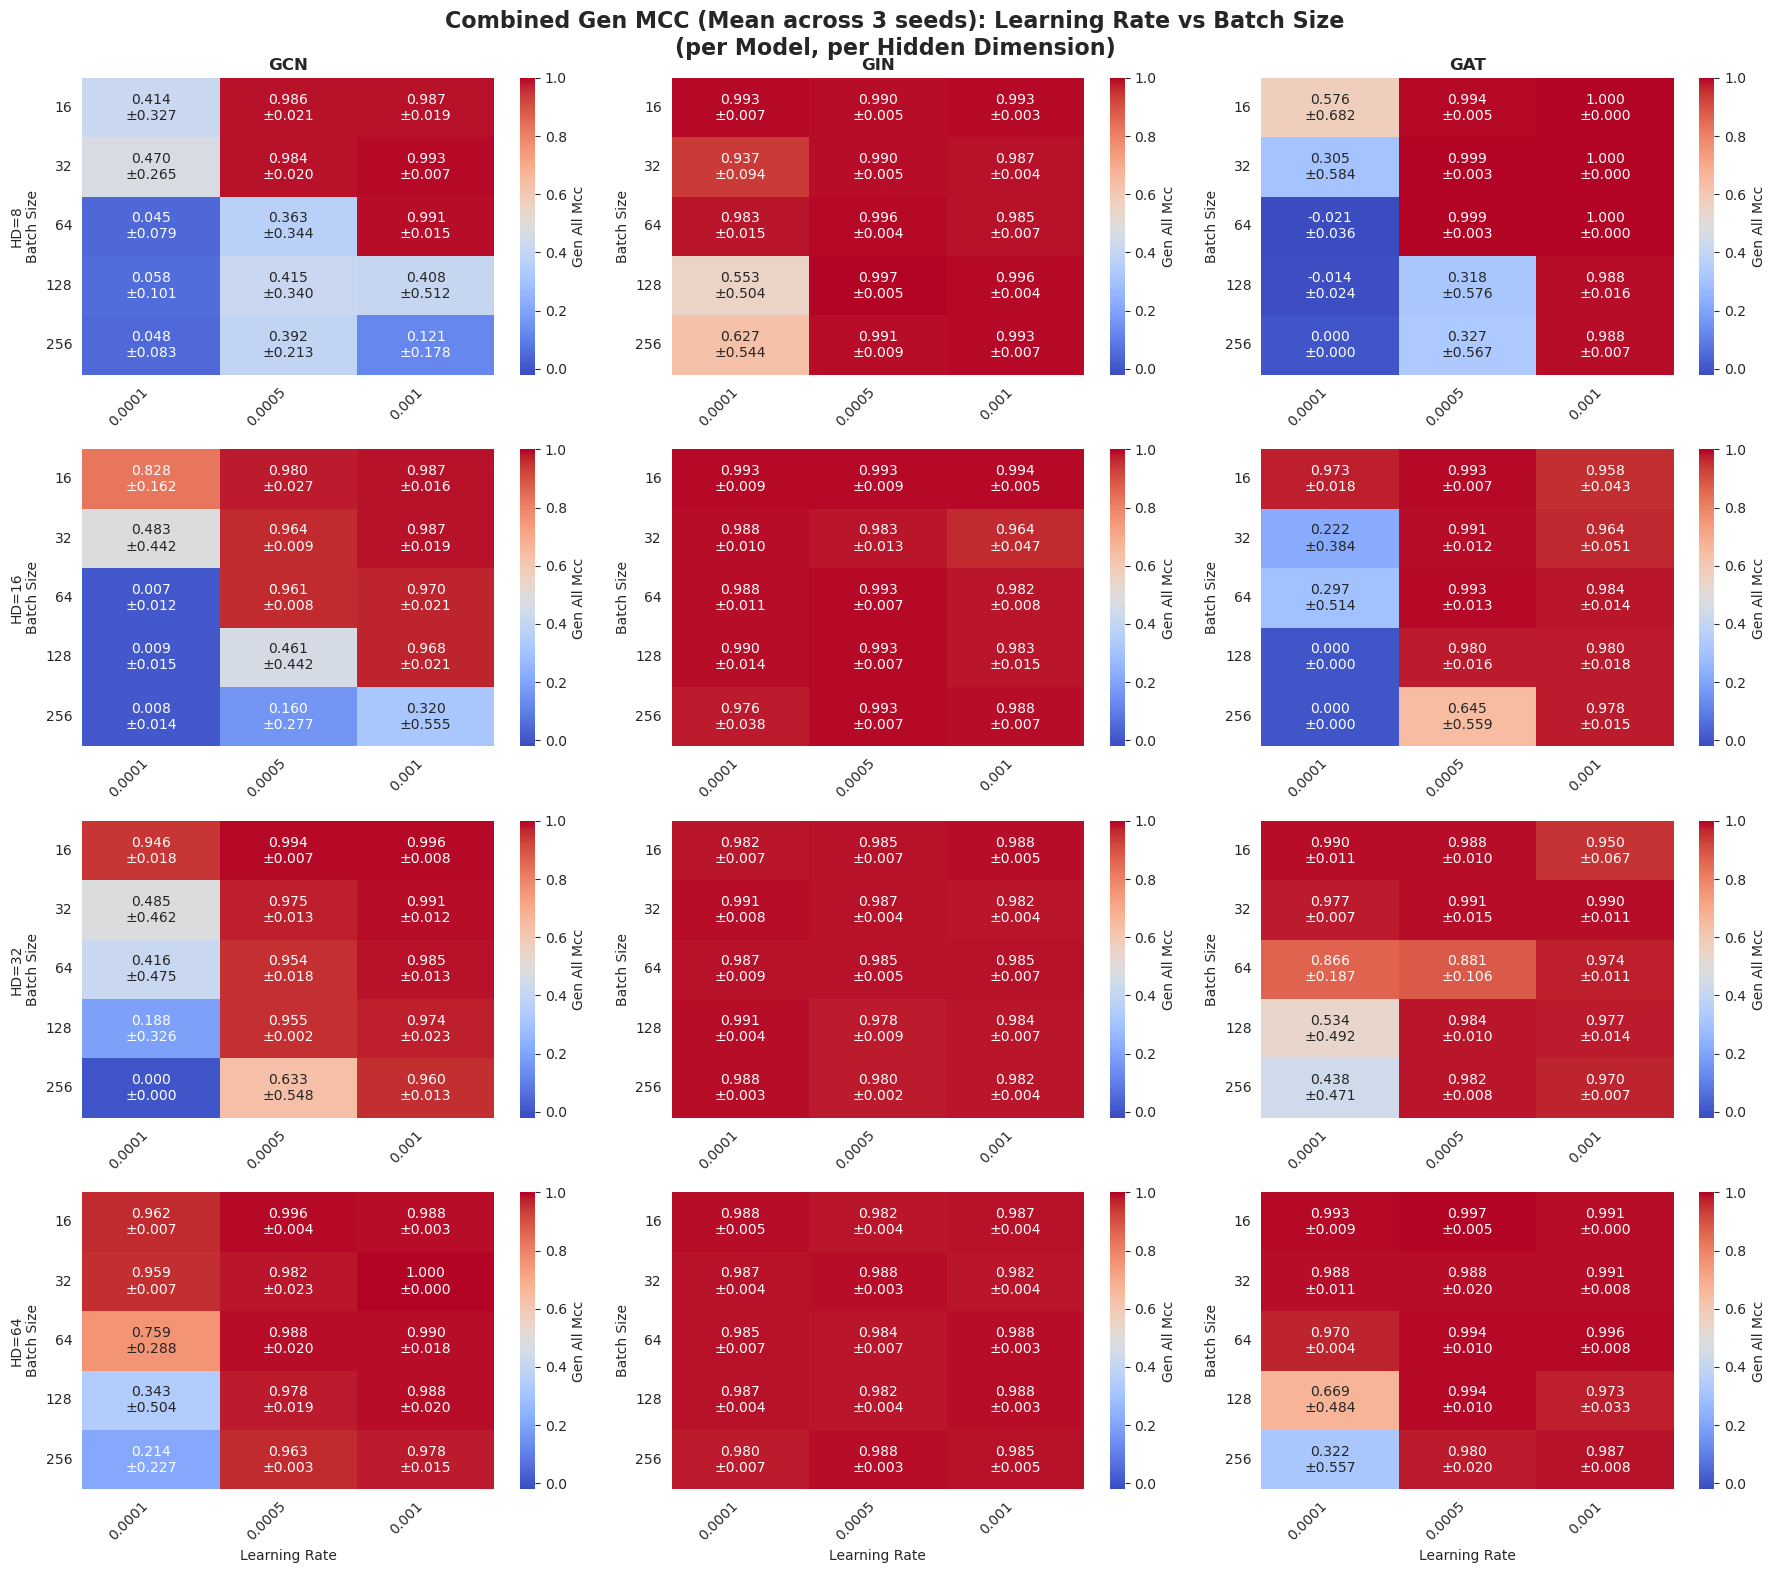

Visualization saved to: combined_gen_mcc_heatmaps.png


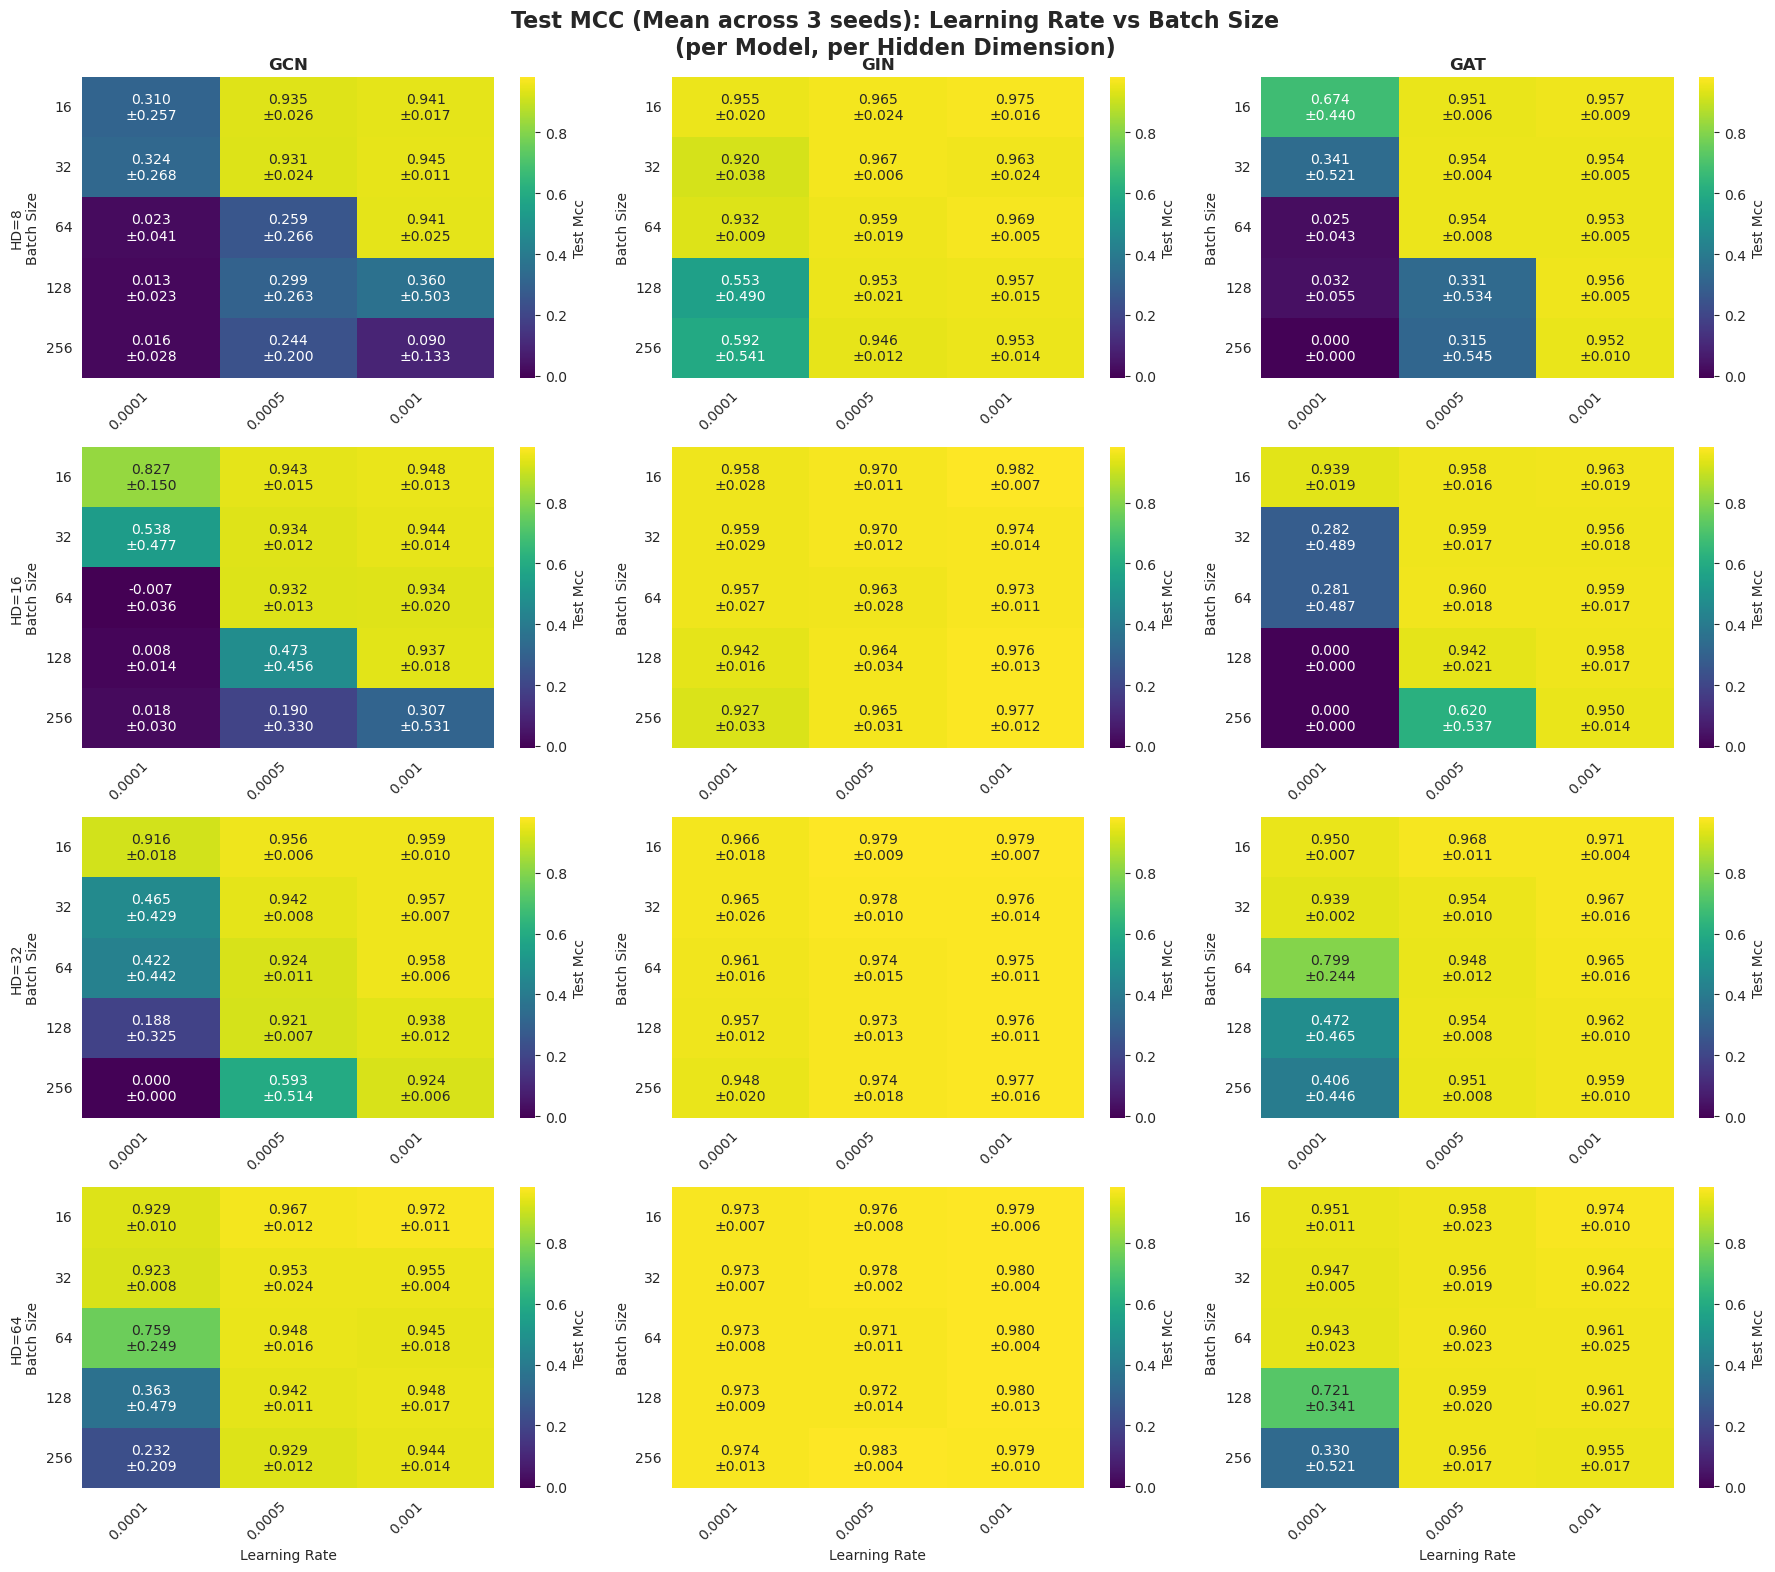

Visualization saved to: test_mcc_heatmaps.png

All visualizations use metrics averaged across 3 random seeds for robustness.


In [33]:
# VISUALIZATIONS

HIDDEN_DIM_GRID = [8, 16, 32, 64]
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
results_per_seed_df = pd.read_csv('hyperparameter_screening_results_per_seed.csv')
results_df = pd.read_csv('hyperparameter_screening_results.csv')

# Set style
sns.set_style("whitegrid")

def create_heatmap_grid(results_df, results_per_seed_df, metric_name, title, filename, cmap='viridis'):
    """Create and save heatmap grid for metric across all models and hidden dimensions, with std annotations."""
    fig, axes = plt.subplots(len(HIDDEN_DIM_GRID), 3, figsize=(18, 16))
    
    # Get global min/max for consistent color scale (based on mean)
    all_values = []
    for model in ['gcn', 'gin', 'gat']:
        all_values.extend(results_df[f'{model}_{metric_name}'].values)
    vmin_global, vmax_global = min(all_values), max(all_values)
    
    for hd_idx, hidden_dim in enumerate(HIDDEN_DIM_GRID):
        for model_idx, (model, model_name) in enumerate(zip(['gcn', 'gin', 'gat'], ['GCN', 'GIN', 'GAT'])):
            ax = axes[hd_idx, model_idx]
            
            # Get mean values
            subset = results_df[results_df['hidden_dim'] == hidden_dim]
            pivot_table = subset.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Get std values from per-seed results
            subset_per_seed = results_per_seed_df[results_per_seed_df['hidden_dim'] == hidden_dim]
            metric_cols_std = [col for col in subset_per_seed.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
            std_df = subset_per_seed.groupby(['batch_size', 'learning_rate'])[metric_cols_std].std().reset_index()
            pivot_std = std_df.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Create custom annotations with mean and std
            annot_data = []
            for i, bs in enumerate(pivot_table.index):
                row = []
                for lr in pivot_table.columns:
                    mean_val = pivot_table.loc[bs, lr]
                    std_val = pivot_std.loc[bs, lr] if (bs in pivot_std.index and lr in pivot_std.columns) else 0.0
                    row.append(f'{mean_val:.3f}\n±{std_val:.3f}')
                annot_data.append(row)
            
            sns.heatmap(pivot_table, annot=annot_data, fmt='', cmap=cmap, ax=ax,
                        cbar_kws={'label': metric_name.replace('_', ' ').title()}, 
                        vmin=vmin_global, vmax=vmax_global)
            
            if hd_idx == 0:
                ax.set_title(model_name, fontsize=12, fontweight='bold')
            if model_idx == 0:
                ax.set_ylabel(f'HD={hidden_dim}\nBatch Size', fontsize=10)
            else:
                ax.set_ylabel('Batch Size', fontsize=10)
            if hd_idx == len(HIDDEN_DIM_GRID) - 1:
                ax.set_xlabel('Learning Rate', fontsize=10)
            else:
                ax.set_xlabel('')
            
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Visualization saved to: {filename}")

# Create heatmaps
create_heatmap_grid(results_df, results_per_seed_df, 'gen_all_mcc', 
                   'Combined Gen MCC (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'combined_gen_mcc_heatmaps.png', cmap='coolwarm')

create_heatmap_grid(results_df, results_per_seed_df, 'test_mcc',
                   'Test MCC (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'test_mcc_heatmaps.png', cmap='viridis')

print("\nAll visualizations use metrics averaged across 3 random seeds for robustness.")



In [34]:
#use optuna Bayes to find best hyperparameters based on test MCC
import optuna

def objective(trial, model_class):
    # Suggest hyperparameters
    batch_size = trial.suggest_categorical('batch_size', BATCH_SIZE_GRID)
    hidden_dim = trial.suggest_categorical('hidden_dim', HIDDEN_DIM_GRID)
    lr = trial.suggest_categorical('learning_rate', LEARNING_RATE_GRID)
    
    results_per_seed = []

    for seed in RANDOM_SEED_GRID:
        # Split data
        train_loader_temp, val_loader_temp, test_loader_temp = split_dataframe(dataset, y, seed, batch_size)
        
        # Train model
        model_temp, thr_temp, test_accuracy, test_mcc = training_and_evaluation(
            model_class=model_class,
            train_loader=train_loader_temp, 
            val_loader=val_loader_temp, 
            test_loader=test_loader_temp, 
            num_features=num_features,
            hidden_dim=hidden_dim,
            seed=seed,
            lr=lr,
        )
        results_per_seed.append({
            'batch_size': batch_size,
            'hidden_dim': hidden_dim,
            'learning_rate': lr,
            'random_seed': seed,
            'test_mcc': test_mcc
        })

    # Return average test MCC across seeds (or you could choose best seed)
    avg_mcc = np.mean([r['test_mcc'] for r in results_per_seed])
    print(f"{model_class.__name__} Trial with batch_size={batch_size}, hidden_dim={hidden_dim}, lr={lr} | Avg Test MCC across seeds: {avg_mcc:.4f}")
    return avg_mcc

study = optuna.create_study(direction='maximize')
for i in [GCN, GIN, GAT]:
    study.optimize(lambda trial: objective(trial, i), n_trials=20)

[I 2026-02-05 10:59:09,574] A new study created in memory with name: no-name-f50015c7-2b75-49c2-aae3-b0929b16a6be



Training model: GCN
Epoch 05 | Train Loss: 0.8453 | Val MCC (opt thr): 0.5991
Epoch 10 | Train Loss: 0.5667 | Val MCC (opt thr): 0.8892
Epoch 15 | Train Loss: 0.3324 | Val MCC (opt thr): 0.9310
Epoch 20 | Train Loss: 0.2800 | Val MCC (opt thr): 0.9434
Epoch 25 | Train Loss: 0.2473 | Val MCC (opt thr): 0.9481
Epoch 30 | Train Loss: 0.2307 | Val MCC (opt thr): 0.9529
Early stopping at epoch 35 | Best MCC: 0.9529
Optimized threshold: 0.800
Test Accuracy: 0.9742
Test MCC: 0.9452

Training model: GCN
Epoch 05 | Train Loss: 0.8628 | Val MCC (opt thr): 0.3096
Epoch 10 | Train Loss: 0.7552 | Val MCC (opt thr): 0.8843
Epoch 15 | Train Loss: 0.4495 | Val MCC (opt thr): 0.9295
Epoch 20 | Train Loss: 0.3106 | Val MCC (opt thr): 0.9389
Epoch 25 | Train Loss: 0.2660 | Val MCC (opt thr): 0.9374
Early stopping at epoch 26 | Best MCC: 0.9405
Optimized threshold: 0.700
Test Accuracy: 0.9687
Test MCC: 0.9303

Training model: GCN
Epoch 05 | Train Loss: 0.8373 | Val MCC (opt thr): 0.7066
Epoch 10 | Train 

[I 2026-02-05 11:00:38,523] Trial 0 finished with value: 0.9314430673874391 and parameters: {'batch_size': 64, 'hidden_dim': 16, 'learning_rate': 0.0005}. Best is trial 0 with value: 0.9314430673874391.


Test Accuracy: 0.9613
Test MCC: 0.9188
GCN Trial with batch_size=64, hidden_dim=16, lr=0.0005 | Avg Test MCC across seeds: 0.9314

Training model: GCN
Epoch 05 | Train Loss: 0.2697 | Val MCC (opt thr): 0.9513
Epoch 10 | Train Loss: 0.2029 | Val MCC (opt thr): 0.9626
Epoch 15 | Train Loss: 0.1568 | Val MCC (opt thr): 0.9673
Epoch 20 | Train Loss: 0.1409 | Val MCC (opt thr): 0.9704
Early stopping at epoch 25 | Best MCC: 0.9704
Optimized threshold: 0.650
Test Accuracy: 0.9803
Test MCC: 0.9582

Training model: GCN
Epoch 05 | Train Loss: 0.2629 | Val MCC (opt thr): 0.9280
Epoch 10 | Train Loss: 0.1869 | Val MCC (opt thr): 0.9374
Early stopping at epoch 14 | Best MCC: 0.9374
Optimized threshold: 0.800
Test Accuracy: 0.9659
Test MCC: 0.9241

Training model: GCN
Epoch 05 | Train Loss: 0.2444 | Val MCC (opt thr): 0.9382
Epoch 10 | Train Loss: 0.1745 | Val MCC (opt thr): 0.9446
Epoch 15 | Train Loss: 0.1275 | Val MCC (opt thr): 0.9510
Epoch 20 | Train Loss: 0.1070 | Val MCC (opt thr): 0.9526
Epo

[I 2026-02-05 11:01:50,653] Trial 1 finished with value: 0.9449237845820971 and parameters: {'batch_size': 64, 'hidden_dim': 64, 'learning_rate': 0.001}. Best is trial 1 with value: 0.9449237845820971.


...

Test Accuracy: 0.9879
Test MCC: 0.9746
GAT Trial with batch_size=16, hidden_dim=32, lr=0.001 | Avg Test MCC across seeds: 0.9768

Training model: GAT
Epoch 05 | Train Loss: 0.8380 | Val MCC (opt thr): 0.3544
Epoch 10 | Train Loss: 0.4255 | Val MCC (opt thr): 0.9054
Epoch 15 | Train Loss: 0.2770 | Val MCC (opt thr): 0.9450
Epoch 20 | Train Loss: 0.2208 | Val MCC (opt thr): 0.9529
Epoch 25 | Train Loss: 0.1837 | Val MCC (opt thr): 0.9627
Epoch 30 | Train Loss: 0.1587 | Val MCC (opt thr): 0.9688
Epoch 35 | Train Loss: 0.1377 | Val MCC (opt thr): 0.9720
Epoch 40 | Train Loss: 0.1247 | Val MCC (opt thr): 0.9735
Early stopping at epoch 42 | Best MCC: 0.9735
Optimized threshold: 0.500
Test Accuracy: 0.9841
Test MCC: 0.9662

Training model: GAT
Epoch 05 | Train Loss: 0.8508 | Val MCC (opt thr): 0.8266
Epoch 10 | Train Loss: 0.5815 | Val MCC (opt thr): 0.8939
Epoch 15 | Train Loss: 0.3019 | Val MCC (opt thr): 0.9251
Epoch 20 | Train Loss: 0.2569 | Val MCC (opt thr): 0.9296
Epoch 25 | Train Loss

[I 2026-02-05 12:35:44,733] Trial 58 finished with value: 0.9500524638084213 and parameters: {'batch_size': 256, 'hidden_dim': 16, 'learning_rate': 0.001}. Best is trial 38 with value: 0.9785395742543255.


Test Accuracy: 0.9719
Test MCC: 0.9414
GAT Trial with batch_size=256, hidden_dim=16, lr=0.001 | Avg Test MCC across seeds: 0.9501

Training model: GAT
Epoch 05 | Train Loss: 0.2721 | Val MCC (opt thr): 0.9465
Epoch 10 | Train Loss: 0.1988 | Val MCC (opt thr): 0.9627
Epoch 15 | Train Loss: 0.1381 | Val MCC (opt thr): 0.9733
Epoch 20 | Train Loss: 0.1293 | Val MCC (opt thr): 0.9734
Early stopping at epoch 24 | Best MCC: 0.9749
Optimized threshold: 0.100
Test Accuracy: 0.9772
Test MCC: 0.9517

Training model: GAT
Epoch 05 | Train Loss: 0.2766 | Val MCC (opt thr): 0.9327
Epoch 10 | Train Loss: 0.1483 | Val MCC (opt thr): 0.9517
Epoch 15 | Train Loss: 0.0909 | Val MCC (opt thr): 0.9640
Epoch 20 | Train Loss: 0.0555 | Val MCC (opt thr): 0.9750
Epoch 25 | Train Loss: 0.0454 | Val MCC (opt thr): 0.9781
Epoch 30 | Train Loss: 0.0455 | Val MCC (opt thr): 0.9781
Early stopping at epoch 33 | Best MCC: 0.9797
Optimized threshold: 0.800
Test Accuracy: 0.9875
Test MCC: 0.9720

Training model: GAT
Epo

[I 2026-02-05 12:38:53,341] Trial 59 finished with value: 0.9545928716481812 and parameters: {'batch_size': 16, 'hidden_dim': 16, 'learning_rate': 0.0005}. Best is trial 38 with value: 0.9785395742543255.


Test Accuracy: 0.9712
Test MCC: 0.9400
GAT Trial with batch_size=16, hidden_dim=16, lr=0.0005 | Avg Test MCC across seeds: 0.9546


In [ ]:
#[I 2026-02-05 12:01:48,025] Trial 38 finished with value: 0.9785395742543255 and parameters: {'batch_size': 256, 'hidden_dim': 16, 'learning_rate': 0.001}. Best is trial 38 with value: 0.9785395742543255.
#use GIN with batch_size=256, hidden_dim=16, learning_rate=0.001 to train final model and evaluate on gen sets
BATCH_SIZE = 256
HIDDEN_DIM = 16
LEARNING_RATE = 0.001
RANDOM_SEED = 42
final_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE), num_features, seed=RANDOM_SEED)
final_gen_all_acc, final_gen_all_mcc = predict_combined_accuracy_and_mcc(
    final_model,
    [
        (gen_set_combined, 0),
        (cov_dock_set, 1),
    ],
    thr,
    BATCH_SIZE,
    device,
)
print(f"Final Model (GIN) Combined Gen Accuracy: {final_gen_all_acc:.4f}, Combined Gen MCC: {final_gen_all_mcc:.4f}")


Training model: GIN
Epoch 05 | Train Loss: 0.2484 | Val MCC (opt thr): 0.9687
Epoch 10 | Train Loss: 0.1088 | Val MCC (opt thr): 0.9922
Early stopping at epoch 15 | Best MCC: 0.9922
Optimized threshold: 0.600
Test Accuracy: 0.9962
Test MCC: 0.9920
Final Model (GIN) Combined Gen Accuracy: 0.9910, Combined Gen MCC: 0.9781


In [47]:
#try with seed 41
RANDOM_SEED = 41
final_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE), num_features, seed=RANDOM_SEED)
final_gen_all_acc, final_gen_all_mcc = predict_combined_accuracy_and_mcc(
    final_model,
    [
        (gen_set_combined, 0),
        (cov_dock_set, 1),
    ],
    thr,
    BATCH_SIZE,
    device,
)
print(f"Final Model (GIN) Combined Gen Accuracy: {final_gen_all_acc:.4f}, Combined Gen MCC: {final_gen_all_mcc:.4f}")


Training model: GIN
Epoch 05 | Train Loss: 0.1761 | Val MCC (opt thr): 0.9507
Epoch 10 | Train Loss: 0.0876 | Val MCC (opt thr): 0.9770
Epoch 15 | Train Loss: 0.0624 | Val MCC (opt thr): 0.9853
Early stopping at epoch 20 | Best MCC: 0.9853
Optimized threshold: 0.350
Test Accuracy: 0.9909
Test MCC: 0.9809
Final Model (GIN) Combined Gen Accuracy: 0.9928, Combined Gen MCC: 0.9824


In [48]:
#try with seed 43
RANDOM_SEED = 43
final_model, thr, _, _ = training_and_evaluation(GIN, *split_dataframe(dataset, y, seed=RANDOM_SEED, batch_size=BATCH_SIZE), num_features, seed=RANDOM_SEED)
final_gen_all_acc, final_gen_all_mcc = predict_combined_accuracy_and_mcc(
    final_model,
    [
        (gen_set_combined, 0),
        (cov_dock_set, 1),
    ],
    thr,
    BATCH_SIZE,
    device,
)
print(f"Final Model (GIN) Combined Gen Accuracy: {final_gen_all_acc:.4f}, Combined Gen MCC: {final_gen_all_mcc:.4f}")


Training model: GIN
Epoch 05 | Train Loss: 0.2506 | Val MCC (opt thr): 0.9813
Epoch 10 | Train Loss: 0.1294 | Val MCC (opt thr): 0.9875
Early stopping at epoch 13 | Best MCC: 0.9891
Optimized threshold: 0.600
Test Accuracy: 0.9818
Test MCC: 0.9623
Final Model (GIN) Combined Gen Accuracy: 0.9910, Combined Gen MCC: 0.9781
